In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

train = pd.read_csv("diabetes_train_preprocessed.csv")
test = pd.read_csv("diabetes_test_preprocessed.csv")

X_train = train.drop("Outcome", axis=1)
y_train = train["Outcome"]

X_test = test.drop("Outcome", axis=1)
y_test = test["Outcome"]

feature_names = X_train.columns

In [2]:
def fit_and_collect(name, penalty, C, class_weight, solver="liblinear", max_iter=1000):
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        class_weight=class_weight,
        solver=solver,
        random_state=42,
        max_iter=max_iter
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T

    coef = model.coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "odds_ratio": np.exp(coef)
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=False)

    return {
        "name": name,
        "model": model,
        "auc": auc,
        "report_df": report_df,
        "coef_df": coef_df
    }


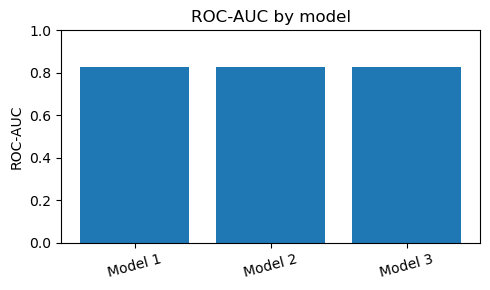

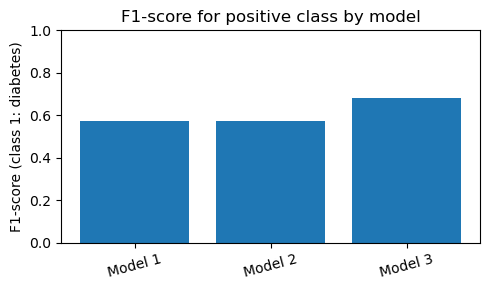

In [3]:
results = []

results.append(
    fit_and_collect(
        name="Model 1",
        penalty="l2",
        C=1.0,
        class_weight=None
    )
)

results.append(
    fit_and_collect(
        name="Model 2",
        penalty="l2",
        C=0.1,
        class_weight=None
    )
)

results.append(
    fit_and_collect(
        name="Model 3",
        penalty="l2",
        C=1.0,
        class_weight="balanced"
    )
)

model_names = [r["name"] for r in results]
auc_values = [r["auc"] for r in results]
f1_positive = [r["report_df"].loc["1", "f1-score"] for r in results]

plt.figure(figsize=(5, 3))
plt.bar(model_names, auc_values)
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.title("ROC-AUC by model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.bar(model_names, f1_positive)
plt.ylabel("F1-score (class 1: diabetes)")
plt.ylim(0, 1)
plt.title("F1-score for positive class by model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


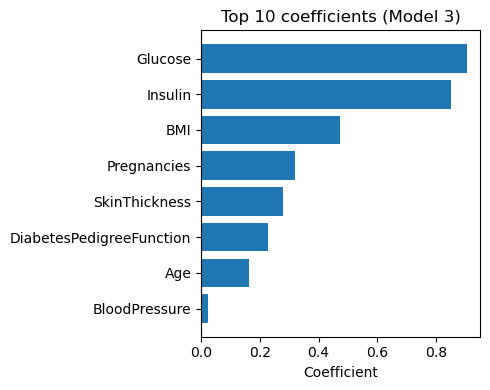

In [4]:
best_result = max(results, key=lambda r: r["auc"])
best_coef_df = best_result["coef_df"].head(10)

plt.figure(figsize=(5, 4))
plt.barh(best_coef_df["feature"], best_coef_df["coef"])
plt.axvline(0, linestyle="--")
plt.xlabel("Coefficient")
plt.title(f"Top 10 coefficients ({best_result['name']})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


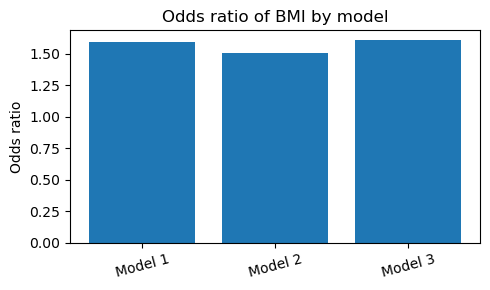

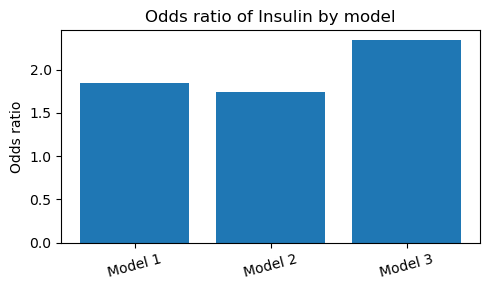

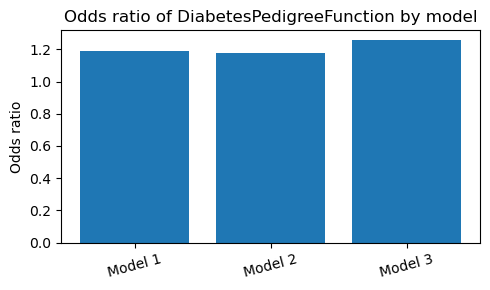

In [5]:
target_vars = ["BMI", "Insulin", "DiabetesPedigreeFunction"]

rows = []
for r in results:
    for feat in target_vars:
        odds = r["coef_df"].loc[r["coef_df"]["feature"] == feat, "odds_ratio"].values[0]
        rows.append({"model": r["name"], "feature": feat, "odds_ratio": odds})

odds_df = pd.DataFrame(rows)

for feat in target_vars:
    sub = odds_df[odds_df["feature"] == feat]
    plt.figure(figsize=(5, 3))
    plt.bar(sub["model"], sub["odds_ratio"])
    plt.ylabel("Odds ratio")
    plt.title(f"Odds ratio of {feat} by model")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()



<보조 변수들(Age 등)과 주요 요인 간 상관계수>
                Glucose       BMI   Insulin  DiabetesPedigreeFunction
Age            0.291619  0.030259  0.153034                  0.025108
Pregnancies    0.140044  0.015981  0.099564                 -0.051994
BloodPressure  0.222328  0.272633  0.107687                 -0.005018
SkinThickness  0.258584  0.560061  0.272089                  0.112087


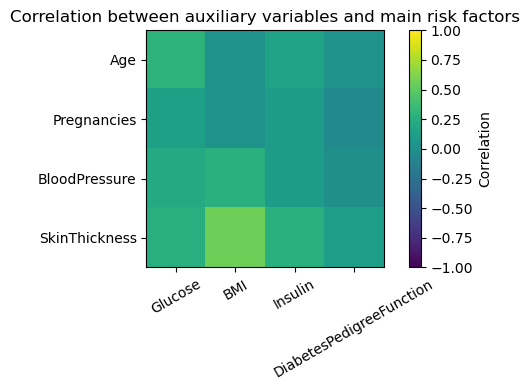

In [6]:
main_vars = ["Glucose", "BMI", "Insulin", "DiabetesPedigreeFunction"]

aux_vars = ["Age", "Pregnancies", "BloodPressure", "SkinThickness"]

all_vars = main_vars + aux_vars

corr = train[all_vars].corr(method="pearson")

sub_corr = corr.loc[aux_vars, main_vars]

print("\n<보조 변수들(Age 등)과 주요 요인 간 상관계수>")
print(sub_corr)

plt.figure(figsize=(6, 4))
plt.imshow(sub_corr, vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(main_vars)), main_vars, rotation=30)
plt.yticks(range(len(aux_vars)), aux_vars)
plt.title("Correlation between auxiliary variables and main risk factors")
plt.tight_layout()
plt.show()
